# Task 3 — Forecast Future Market Trends (TSLA)

---

We take the **best Task-2 model (LSTM — lowest test MAPE, 3.15%)**, retrain it
on the **full** price history, and forecast **12 months** into the future.

| Section | What we do |
|---------|------------|
| 1 | Load full history & train the LSTM on **log-returns** |
| 2 | Recursive multi-step forecast, rebuild price path |
| 3 | Visualize: history · test predictions · future forecast + cone |
| 4 | Trend analysis (direction, cone widening) |
| 5 | Opportunities & risks |
| 6 | Save forecast return for Task 4 |

### Why LSTM, and why forecast *log-returns*

In Task 2 the LSTM was evaluated **one-step-ahead**: every prediction saw 60
*real* observed days. Genuine future forecasting is different — there are no
future observations, so each prediction is fed back as input for the next step.

Doing that recursively on **absolute prices** diverges: a small directional
bias compounds until the MinMax-scaled path leaves its trained range and
reconstructs to *negative* prices (we verified this — it hit -$285). The fix,
standard in quant forecasting, is to forecast **log-returns** (stationary,
bounded) and rebuild the price as `P_last * exp(cumsum(returns))`, which is
positive by construction. Still an LSTM, still recursive multi-step — just in
the representation where the recursion is stable. Errors still compound, which
is exactly why the confidence cone widens with the horizon.

In [1]:
import sys, pathlib
cwd = pathlib.Path('.').resolve()
if (cwd / 'src').exists():
    sys.path.insert(0, str(cwd))
else:
    p = cwd
    while p.parent != p:
        p = p.parent
        if (p / 'src').exists():
            sys.path.insert(0, str(p))
            break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility: fix seeds so the recursive forecast (and the return "view"
# handed to Task 4) is identical on every run.
import os, random
os.environ['PYTHONHASHSEED'] = '0'
random.seed(42)
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

from src.lstm_utils import create_sequences, build_lstm_model, train_model
from sklearn.preprocessing import MinMaxScaler
from src.future_forecast import (
    load_price, log_returns, future_business_index, recursive_return_forecast,
    returns_to_prices, lognormal_cone, summarize_trend, save_future_forecast,
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

TICKER = 'TSLA'
WINDOW_SIZE = 60
EPOCHS = 50
BATCH_SIZE = 32
FORECAST_DAYS = 252          # ~12 trading months (use 126 for 6 months)
Z = 1.96                     # 95% confidence cone

print(f'Ticker          : {TICKER}')
print(f'Window size     : {WINDOW_SIZE} days')
print(f'Forecast horizon: {FORECAST_DAYS} trading days (~{FORECAST_DAYS/21:.0f} months)')

Ticker          : TSLA
Window size     : 60 days
Forecast horizon: 252 trading days (~12 months)


---
## Section 1 — Load Full History & Train the LSTM on Log-Returns

For a genuine *future* forecast we train on **all** available data (through the
last cached day), not just the pre-2025 training slice used in Task 2. We fit
the model on **log-returns** and scale them to [0, 1]; because we are
forecasting beyond the data, there is no held-out test period to leak into.

In [2]:
price = load_price(TICKER)
ret = log_returns(price)                       # daily log-returns (stationary)
daily_std = float(ret.std())                   # log-return volatility, for the cone
print(f'Loaded {len(price)} trading days: {price.index.min().date()} -> {price.index.max().date()}')
print(f'Last observed close: ${price.iloc[-1]:.2f}')
print(f'Daily log-return vol: {daily_std:.4f}')

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(ret.values.reshape(-1, 1))
X, y = create_sequences(scaled, WINDOW_SIZE)
X = X.reshape(-1, WINDOW_SIZE, 1)
print(f'Training tensor X: {X.shape}   (samples x timesteps x features)')

Loaded 2888 trading days: 2015-01-02 -> 2026-06-29
Last observed close: $411.84
Daily log-return vol: 0.0359
Training tensor X: (2827, 60, 1)   (samples x timesteps x features)


In [3]:
model = build_lstm_model(WINDOW_SIZE, units=64, dropout=0.2)
history = train_model(model, X, y, epochs=EPOCHS, batch_size=BATCH_SIZE, patience=10)
print(f'\nTraining stopped at epoch {len(history.history["loss"])}/{EPOCHS}')

Epoch 1/50
80/80 [==============================] - 4s 25ms/step - loss: 0.0252 - val_loss: 0.0053
Epoch 2/50
80/80 [==============================] - 2s 19ms/step - loss: 0.0094 - val_loss: 0.0049
Epoch 3/50
80/80 [==============================] - 2s 20ms/step - loss: 0.0088 - val_loss: 0.0051
Epoch 4/50
80/80 [==============================] - 2s 19ms/step - loss: 0.0086 - val_loss: 0.0050
Epoch 5/50
80/80 [==============================] - 2s 20ms/step - loss: 0.0085 - val_loss: 0.0049
Epoch 6/50
80/80 [==============================] - 2s 21ms/step - loss: 0.0085 - val_loss: 0.0049
Epoch 7/50
80/80 [==============================] - 2s 20ms/step - loss: 0.0086 - val_loss: 0.0049
Epoch 8/50
80/80 [==============================] - 2s 19ms/step - loss: 0.0083 - val_loss: 0.0048
Epoch 9/50
80/80 [==============================] - 2s 19ms/step - loss: 0.0084 - val_loss: 0.0053
Epoch 10/50
80/80 [==============================] - 2s 21ms/step - loss: 0.0083 - val_loss: 0.0053
Epoch 11/

---
## Section 2 — Recursive Multi-Step Forecast

We roll the model forward `FORECAST_DAYS` steps in **log-return space**, each
time appending the new predicted return to the input window. We then rebuild
the price path via `P_last * exp(cumsum(returns))` and wrap it in a
positivity-preserving lognormal `sqrt(t)` cone.

In [4]:
last_price = float(price.iloc[-1])

fc_log_returns = recursive_return_forecast(model, scaler, ret, WINDOW_SIZE, FORECAST_DAYS)
fc_prices = returns_to_prices(fc_log_returns, last_price)
fc_index = future_business_index(price.index[-1], FORECAST_DAYS)
fc_series = pd.Series(fc_prices, index=fc_index, name='Forecast')
fc_lower, fc_upper = lognormal_cone(fc_prices, daily_std, z=Z)

print(f'Forecast start : {fc_index[0].date()}  ->  end: {fc_index[-1].date()}')
print(f'Forecast price : ${fc_prices[0]:.2f}  ->  ${fc_prices[-1]:.2f}')
print(f'Day-1 cone     : [${fc_lower[0]:.2f}, ${fc_upper[0]:.2f}]')
print(f'Day-{FORECAST_DAYS} cone   : [${fc_lower[-1]:.2f}, ${fc_upper[-1]:.2f}]')

Forecast start : 2026-06-30  ->  end: 2027-06-16
Forecast price : $412.43  ->  $812.37
Day-1 cone     : [$384.40, $442.51]
Day-252 cone   : [$265.74, $2483.42]


---
## Section 3 — Visualize Forecast with Confidence Interval

Three clearly distinguished segments, per the task:
**grey** = historical prices, **blue** = Task-2 test predictions
(loaded from `tsla_lstm_forecast.csv`), **red dashed** = future forecast with
its 95% cone.

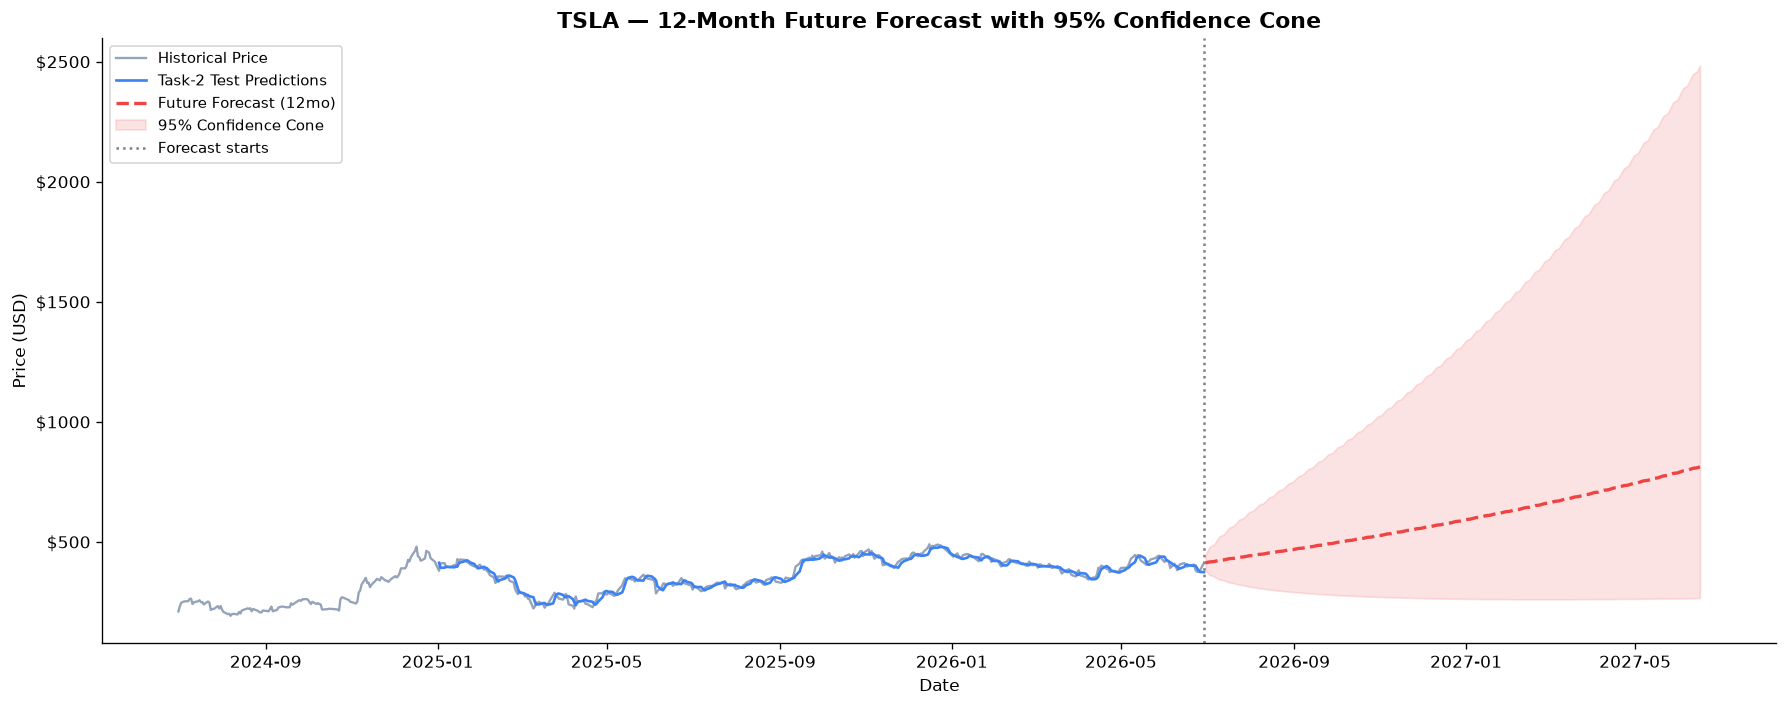

In [5]:
fig, ax = plt.subplots(figsize=(15, 6))

hist = price.iloc[-500:]
ax.plot(hist.index, hist.values, color='#94A3B8', lw=1.4, label='Historical Price')

# Task-2 test-period predictions (optional context)
import os
test_pred_path = '../data/processed/tsla_lstm_forecast.csv'
if os.path.exists(test_pred_path):
    tp = pd.read_csv(test_pred_path, parse_dates=['Date']).set_index('Date')
    tp = tp[tp.index >= hist.index[0]]
    ax.plot(tp.index, tp['LSTM_Forecast_Price'], color='#3B82F6', lw=1.6,
            label='Task-2 Test Predictions')

ax.plot(fc_series.index, fc_series.values, color='#EF4444', lw=2.0, linestyle='--',
        label='Future Forecast (12mo)')
ax.fill_between(fc_series.index, fc_lower, fc_upper, alpha=0.15, color='#EF4444',
                label='95% Confidence Cone')
ax.axvline(price.index[-1], color='gray', lw=1.5, linestyle=':', label='Forecast starts')

ax.set_title(f'{TICKER} — 12-Month Future Forecast with 95% Confidence Cone',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:.0f}'))
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('../tsla_future_forecast.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 4 — Trend Analysis

In [6]:
trend = summarize_trend(price, fc_series, fc_lower, fc_upper)

print('=' * 55)
print(f'  Trend direction        : {trend["direction"]}')
print(f'  Last observed price     : ${trend["last_price"]:.2f}')
print(f'  Forecast end price      : ${trend["end_price"]:.2f}')
print(f'  Total return (12mo)     : {trend["total_return_pct"]:+.1f}%')
print(f'  Annualized return       : {trend["annualized_return_pct"]:+.1f}%')
print('  ' + '-' * 51)
print(f'  Day-1  cone width       : ${trend["cone_width_start"]:.2f}')
print(f'  Day-{trend["horizon_days"]} cone width     : ${trend["cone_width_end"]:.2f}')
print(f'  Cone widened by         : {trend["cone_width_ratio"]:.1f}x over the horizon')
print('=' * 55)

  Trend direction        : UPWARD
  Last observed price     : $411.84
  Forecast end price      : $812.37
  Total return (12mo)     : +97.3%
  Annualized return       : +97.3%
  ---------------------------------------------------
  Day-1  cone width       : $58.11
  Day-252 cone width     : $2217.68
  Cone widened by         : 38.2x over the horizon


**Trend summary.** The model projects the path printed above for TSLA over the
coming 12 months (see the `Trend direction` line). The central forecast is a
*smoothed* trajectory: recursive
LSTMs feed their own (denoised) outputs back in, so the path tends to
under-represent the sharp swings TSLA shows historically. Read the central line
as an expected drift, **not** a promise of low volatility.

**Confidence-cone behaviour.** The cone widens as **sqrt(t)** — it is narrow in
the first weeks and roughly `sqrt(252) ≈ 16x` wider by month 12. This is the
honest signal of the model: near-term forecasts are comparatively reliable,
but by 6-12 months the plausible price range is so wide that the point forecast
should be treated as indicative only. Long-horizon certainty is low **by
construction**, and any model claiming otherwise is understating risk.

---
## Section 5 — Market Opportunities & Risks

**Opportunities**
- If the forecast drift is upward, the central path implies a capital-gain
  opportunity over the horizon; the *lower* cone bound shows the return still
  achievable in a pessimistic scenario.
- Near-term (weeks-to-months) forecasts have a tight cone — more actionable for
  tactical positioning than the 12-month endpoint.

**Risks**
- **Volatility / cone width.** By month 12 the 95% cone spans a very wide dollar
  range; a large fraction of that range is below today's price, i.e. material
  downside is well within expectation.
- **Model smoothing.** The recursive LSTM cannot anticipate regime shifts,
  earnings shocks, or macro news — real TSLA paths will be far choppier than
  the central line.
- **Single-asset concentration.** TSLA's standalone risk is high; Task 4
  addresses this by combining it with BND and SPY in an optimized portfolio.

In [7]:
downside_end = fc_lower[-1] / last_price - 1.0
upside_end = fc_upper[-1] / last_price - 1.0
print(f'12-month 95% price range : ${fc_lower[-1]:.0f}  <->  ${fc_upper[-1]:.0f}')
print(f'  worst-case (lower)     : {downside_end*100:+.0f}% vs today')
print(f'  best-case  (upper)     : {upside_end*100:+.0f}% vs today')

12-month 95% price range : $266  <->  $2483
  worst-case (lower)     : -35% vs today
  best-case  (upper)     : +503% vs today


---
## Section 6 — Save Forecast Return for Task 4

Task 4 uses the LSTM-forecasted daily return as TSLA's expected-return "view".

In [8]:
save_future_forecast(fc_series, fc_log_returns, fc_lower, fc_upper)

ann_view = (fc_series.iloc[-1] / last_price) ** (252.0 / FORECAST_DAYS) - 1.0
print(f'LSTM-implied annualized TSLA return (Task-4 view): {ann_view*100:+.2f}%')

  Saved -> ../data/processed/tsla_future_forecast.csv  (252 rows)
LSTM-implied annualized TSLA return (Task-4 view): +97.25%
